# 05 · What do the predictive features encode?

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir() and (p / "results").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import *

P = paths(ROOT)
FIG = P["figures"]
B, SEED = bootstrap_settings(ROOT)
set_style()
pd.set_option("display.precision", 3)

In [2]:
FI = P["interpretation"]

def tokens(s, n=5):
    if not isinstance(s, str):
        return ""
    return ", ".join(t.strip().strip("'\"") for t in s.split(" | ")[:n])

def load_features(c, k):
    stem = f"{c}_{PRIMARY_HOOKS[c]}_{k}"
    top = pd.read_csv(FI / f"{stem}_top_features.csv")
    top = top[[x for x in ["feature_id", "mean_coef", "std_coef", "n_folds_nonzero", "logit_lens_top20"] if x in top.columns]]
    for suffix, cols in [("neuronpedia", ["np_explanation", "np_url"]),
                         ("srp", ["srp_fidelity", "srp_top_features", "srp_n_active"])]:
        f = FI / f"{stem}_{suffix}.csv"
        if f.exists():
            extra = pd.read_csv(f)
            top = top.merge(extra[["feature_id"] + [x for x in cols if x in extra.columns]], on="feature_id", how="left")
    top["srp_top_dir"] = top.get("srp_top_features", pd.Series(dtype=str)).map(
        lambda s: f"#{json.loads(s)[0][0]}" if isinstance(s, str) and json.loads(s) else "")
    return top.assign(corpus=c, kind=k, hook=PRIMARY_HOOKS[c], logit_lens=top.logit_lens_top20.map(tokens))

feats = pd.concat([load_features(c, k) for c in CORPORA for k in ["post", "prefix"]], ignore_index=True)
feats["label"] = feats.get("np_explanation", pd.Series(index=feats.index, dtype=str)).fillna(feats.logit_lens)
maxact = pd.concat([pd.read_csv(FI / f"{c}_{PRIMARY_HOOKS[c]}_{k}_max_activating.csv").assign(corpus=c, kind=k)
                    for c in CORPORA for k in ["post", "prefix"]], ignore_index=True)
print(f"{len(feats)} features; Neuronpedia labels: {feats.get('np_explanation', pd.Series()).notna().sum()}; "
      f"SRP fidelity: {feats.get('srp_fidelity', pd.Series()).notna().sum()}")

120 features; Neuronpedia labels: 120; SRP fidelity: 120


# Strongest features (filled = longer RT when active, open = shorter)

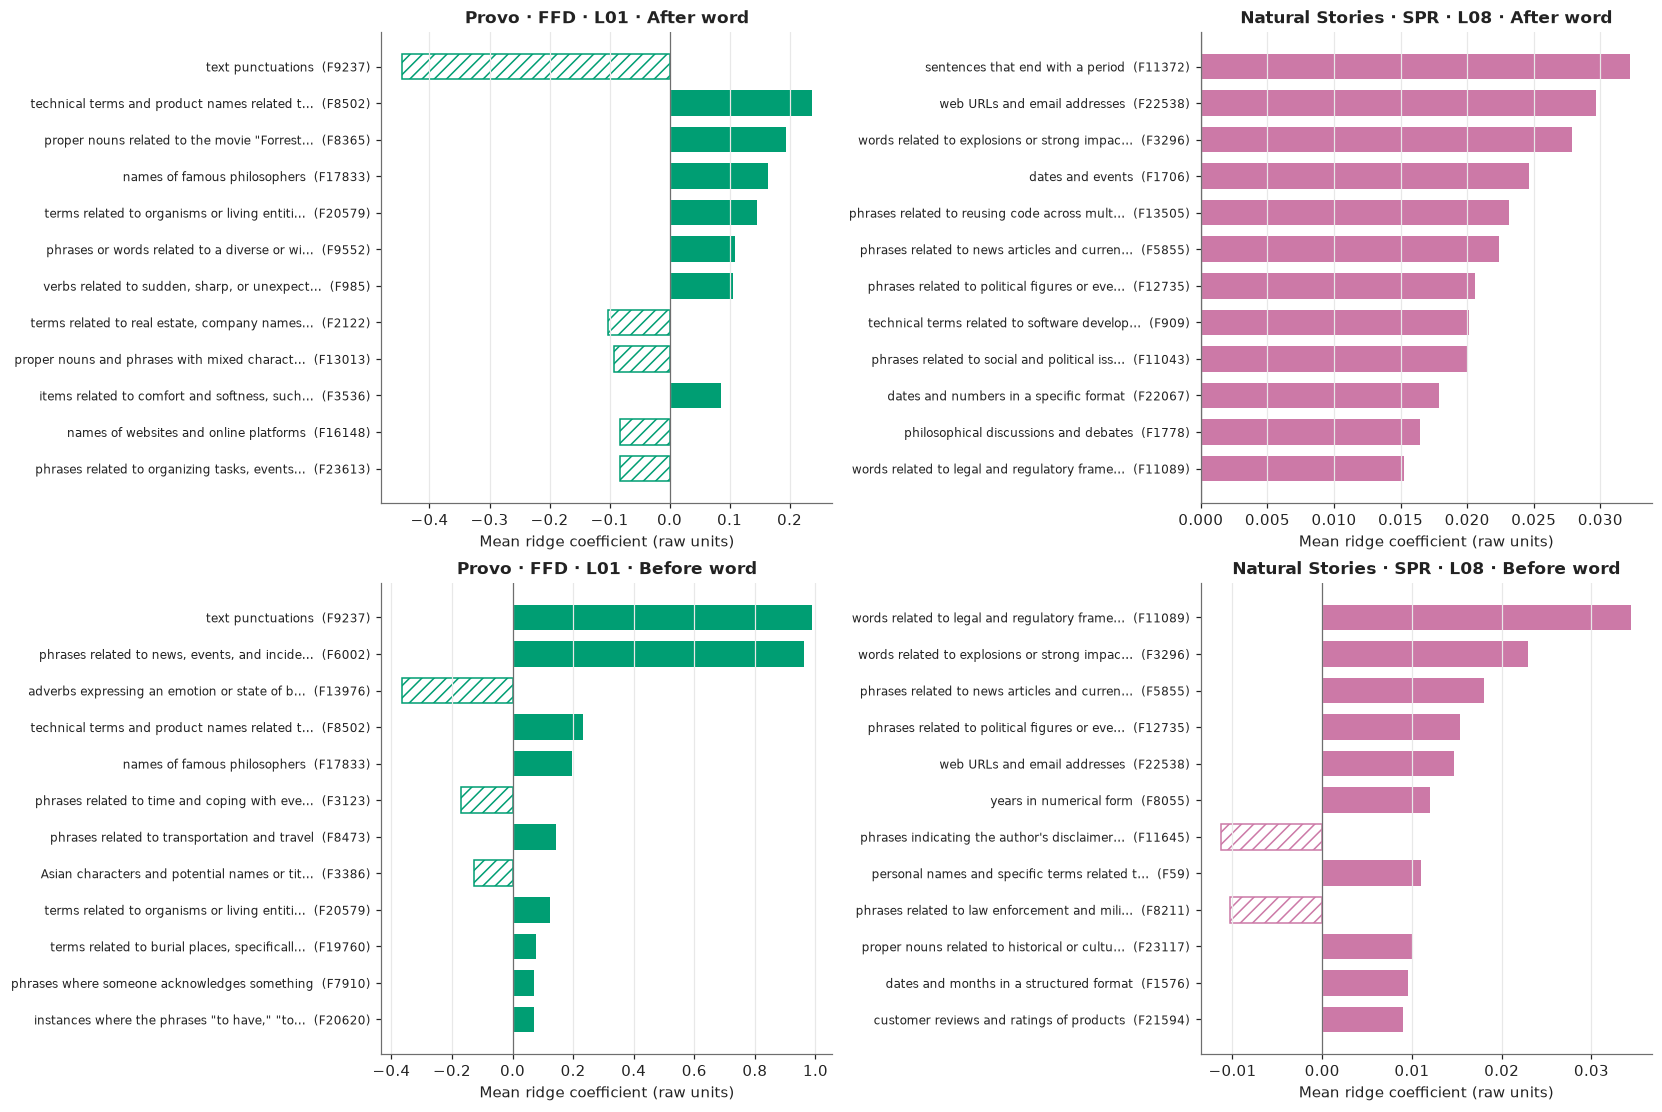

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), layout="constrained")
for j, c in enumerate(CORPORA):
    for i, k in enumerate(["post", "prefix"]):
        ax = axes[i, j]
        f = feats[(feats.corpus == c) & (feats.kind == k)].reindex(
            feats[(feats.corpus == c) & (feats.kind == k)].mean_coef.abs().sort_values(ascending=False).index).head(12)[::-1]
        y = np.arange(len(f))
        pos = f.mean_coef > 0
        ax.barh(y[pos], f.mean_coef[pos], color=CORPUS_COLORS[c], height=0.7)
        ax.barh(y[~pos], f.mean_coef[~pos], color="white", edgecolor=CORPUS_COLORS[c], hatch="///", height=0.7)
        ax.set_yticks(y, [f"{shorten(l, 44)}  (F{int(fid)})" for l, fid in zip(f.label, f.feature_id)], fontsize=8)
        ax.axvline(0, color=MUTED, lw=0.8); ax.grid(axis="x", color=GRID)
        ax.set_title(f"{CORPUS_LABELS[c]} · {PRIMARY_HOOKS[c]} · {STATE_LABELS[k]}")
        ax.set_xlabel("Mean ridge coefficient (raw units)")
save_figure(fig, FIG, "05_top_features"); plt.show()

# Three methods side by side

In [8]:
cols = {"feature_id": "Feature", "mean_coef": "Coef.", "logit_lens": "Logit-lens tokens",
        "np_explanation": "Neuronpedia", "srp_fidelity": "SRP fidelity", "srp_top_dir": "Top SRP dir."}
for c in CORPORA:
    for k in ["post", "prefix"]:
        f = feats[(feats.corpus == c) & (feats.kind == k)]
        f = f.reindex(f.mean_coef.abs().sort_values(ascending=False).index).head(8)
        t = f[[x for x in cols if x in f.columns]].rename(columns=cols)
        t.to_csv(FI / f"three_method_{c}_{k}.csv", index=False)
        display(focus_table(t, formats={"Coef.": "{:+.3f}", "SRP fidelity": "{:.3f}"},
                            caption=f"{CORPUS_LABELS[c]} · {PRIMARY_HOOKS[c]} · {STATE_LABELS[k]}"))

Feature,Coef.,Logit-lens tokens,Neuronpedia,SRP fidelity,Top SRP dir.
9237,-0.446,", <|endoftext|>, , , However",text punctuations,0.495,#2846
8502,+0.237,"irlf, itably, ividual, escription, acebook",technical terms and product names related to computer software and hardware,0.617,#452
8365,+0.193,"Forrest, Rocky, Oprah, motivational, Twain","proper nouns related to the movie ""Forrest Gump""",0.708,#669
17833,+0.165,"philosophers, philosopher, Hegel, philosophical, Nietzsche",names of famous philosophers,0.819,#2412
20579,+0.146,"une, organism, acquaintance, agitated, accustomed",terms related to organisms or living entities,0.797,#4033
9552,+0.109,"enigmatic, exotic, obscure, absurd, elegant",phrases or words related to a diverse or wide variety of items,0.834,#4033
985,+0.105,"flipped, swapped, dumped, pounded, tossed","verbs related to sudden, sharp, or unexpected actions or changes",0.999,#4047
2122,-0.103,"behavi, CLASSIFIED, antioxid, Balt, suscept","terms related to real estate, company names, and community activities",0.841,#3922


Feature,Coef.,Logit-lens tokens,Neuronpedia,SRP fidelity,Top SRP dir.
9237,+0.988,", <|endoftext|>, , , However",text punctuations,0.495,#2846
6002,+0.961,"rue, roid, rike, cation, mosp","phrases related to news, events, and incidents",0.682,#456
13976,-0.365,"proudly, calmly, confidently, angrily, patiently",adverbs expressing an emotion or state of being followed by words representing a positive or negative characteristic,0.931,#1344
8502,+0.233,"irlf, itably, ividual, escription, acebook",technical terms and product names related to computer software and hardware,0.617,#452
17833,+0.198,"philosophers, philosopher, Hegel, philosophical, Nietzsche",names of famous philosophers,0.819,#2412
3123,-0.170,"the, the, a, its, his",phrases related to time and coping with events,0.769,#1339
8473,+0.145,"passengers, passenger, commuters, travelers, riders",phrases related to transportation and travel,0.829,#4068
3386,-0.126,"antioxid, Seym, Balt, mathemat, millenn","Asian characters and potential names or titles within blocks of text, with a focus on words with unique characters and sequences within them",0.736,#1813


Feature,Coef.,Logit-lens tokens,Neuronpedia,SRP fidelity,Top SRP dir.
11372,+0.032,"Adds, His, Says, He, [",sentences that end with a period,0.630,#3310
22538,+0.030,"agall, dit, nl, retty, radio",web URLs and email addresses,0.717,#165
3296,+0.028,"furnace, asts, ographed, furn, efully",words related to explosions or strong impacts,0.592,#1826
1706,+0.025,"Includes, Appears, Requires, Requires, Includes",dates and events,0.817,#2456
13505,+0.023,"Topics, Introduction, Course, Disclaimer, Instructor",phrases related to reusing code across multiple modules,0.939,#2456
5855,+0.022,"Replay, ?, ], ?], ]",phrases related to news articles and current events,0.721,#2439
12735,+0.021,"himself, pard, pardon, aides, veto",phrases related to political figures or events,0.764,#2765
909,+0.020,"..., </, `, [-,",technical terms related to software development,0.704,#3206


Feature,Coef.,Logit-lens tokens,Neuronpedia,SRP fidelity,Top SRP dir.
11089,+0.034,"advers, enforce, centralized, decentralized, incentiv",words related to legal and regulatory frameworks,0.838,#3796
3296,+0.023,"furnace, asts, ographed, furn, efully",words related to explosions or strong impacts,0.592,#1826
5855,+0.018,"Replay, ?, ], ?], ]",phrases related to news articles and current events,0.721,#2439
12735,+0.015,"himself, pard, pardon, aides, veto",phrases related to political figures or events,0.764,#2765
22538,+0.015,"agall, dit, nl, retty, radio",web URLs and email addresses,0.717,#165
8055,+0.012,"compared, -, adjusted, GDP, onwards",years in numerical form,0.658,#3448
11645,-0.011,"editorial, satire, opinions, trademarks, copyrighted",phrases indicating the author's disclaimer or lack of representation of others' views,0.763,#330
59,+0.011,"Anon, SEE, @@, CAP, istg","personal names and specific terms related to articles, publications, and images",0.739,#816


# SRP fidelity (custom GPT-2 SRP dictionary)

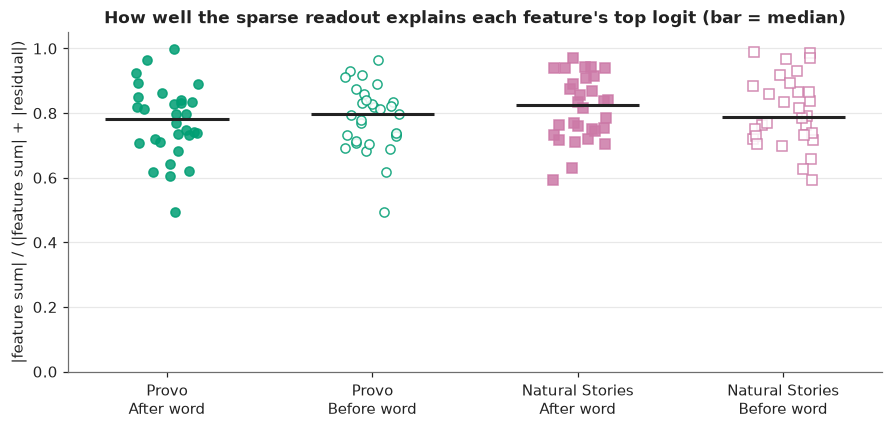

,n,features
srp_top_dir,,
#3922,8,"F2122, F2743, F4319, F8138, F11722, F13953, F1..."
#2456,6,"F1587, F1706, F9552, F13505, F20364, F22243"
#1813,4,"F3386, F3929, F16148, F22196"
#1013,3,"F7910, F20068, F23613"
#1339,3,"F1143, F3123, F20201"
#2483,3,"F7413, F20042, F23052"
#2846,3,"F9237, F15580, F15680"
#1727,2,"F10638, F19278"
#1730,2,"F10681, F13099"


In [5]:
if "srp_fidelity" in feats:
    fig, ax = plt.subplots(figsize=(8, 3.8), layout="constrained")
    rng = np.random.default_rng(0)
    groups = [(c, k) for c in CORPORA for k in ["post", "prefix"]]
    for gi, (c, k) in enumerate(groups):
        v = feats[(feats.corpus == c) & (feats.kind == k)].srp_fidelity.dropna()
        ax.plot(gi + rng.uniform(-0.15, 0.15, len(v)), v, ls="", marker=CORPUS_MARKERS[c], color=CORPUS_COLORS[c],
                mfc=CORPUS_COLORS[c] if k == "post" else "white", ms=6, alpha=0.85)
        ax.hlines(v.median(), gi - 0.3, gi + 0.3, color=INK, lw=2)
    ax.set_xticks(range(len(groups)), [f"{CORPUS_LABELS[c].split(' ·')[0]}\n{STATE_LABELS[k]}" for c, k in groups])
    ax.set_ylabel("|feature sum| / (|feature sum| + |residual|)"); ax.set_ylim(0, 1.05); ax.grid(axis="y", color=GRID)
    ax.set_title("How well the sparse readout explains each feature's top logit (bar = median)")
    save_figure(fig, FIG, "05_srp_fidelity"); plt.show()
    shared = (feats.groupby("srp_top_dir").agg(n=("feature_id", "nunique"),
              features=("feature_id", lambda s: ", ".join(f"F{int(v)}" for v in sorted(set(s)))))
              .query("n > 1 and index != ''").sort_values("n", ascending=False))
    display(shared)

# Case study: feature 9237 at Provo L01 (previous vs current token)

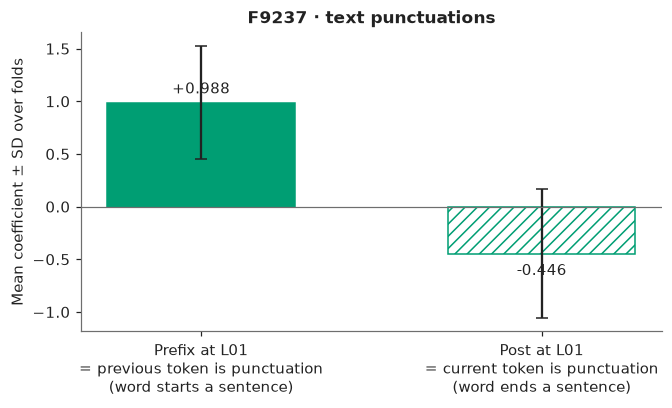

In [6]:
f = feats[(feats.corpus == "provo") & (feats.feature_id == 9237)].set_index("kind")
if len(f) == 2:
    fig, ax = plt.subplots(figsize=(6, 3.6), layout="constrained")
    for i, k in enumerate(["prefix", "post"]):
        v, e = f.loc[k, "mean_coef"], f.loc[k, "std_coef"]
        ax.bar(i, v, yerr=e, capsize=4, width=0.55, color=GREEN if v > 0 else "white", edgecolor=GREEN,
               hatch="" if v > 0 else "///", ecolor=INK)
        ax.annotate(f"{v:+.3f}", (i, v), xytext=(0, 6 if v > 0 else -14), textcoords="offset points", ha="center")
    ax.set_xticks([0, 1], ["Prefix at L01\n= previous token is punctuation\n(word starts a sentence)",
                           "Post at L01\n= current token is punctuation\n(word ends a sentence)"])
    ax.axhline(0, color=MUTED, lw=0.8); ax.set_ylabel("Mean coefficient ± SD over folds")
    ax.set_title(f"F9237 · {shorten(f.label.iloc[0], 40)}")
    save_figure(fig, FIG, "05_f9237"); plt.show()

In [7]:
for c, fid in [("provo", 9237), ("provo", 985), ("provo", 8365), ("natural_stories", 12735)]:
    m = maxact[(maxact.corpus == c) & (maxact.feature_id == fid) & (maxact.kind == "post")].head(3)
    if len(m):
        lab = feats[(feats.corpus == c) & (feats.feature_id == fid)].label.iloc[0]
        print(f"F{fid} ({CORPUS_LABELS[c]}): {lab}")
        for r in m.itertuples():
            print(f"   {r.activation:7.2f}  …{r.context}…")

F9237 (Provo · FFD): text punctuations
      0.01  …two-week stay for previously declining [to] testify before a different grand…
      0.01  …that make up the neck [and] spine, helping them achieve a…
      0.01  …anxiety and prayer that I [and] this nation should be on…
F985 (Provo · FFD): verbs related to sudden, sharp, or unexpected actions or changes
      0.61  …liquid that may form is [drained] off to the sewer or…
      0.29  …the same neurological regions are [invoked] by mental practice as by…
      0.26  …thousand or so was slowly [eroded] by Western disease and deportation…
F8365 (Provo · FFD): proper nouns related to the movie "Forrest Gump"
      0.11  …their hiding-place that they were [gaily] chattering. The pirates listened grimly,…
      0.11  …of its proton shells or [neutron] shells loaded to full capacity,…
      0.08  …with the use of sundials. [Noon] was recognized when the sun…
F12735 (Natural Stories · SPR): phrases related to political figures or events
      